#**This code generates captions from the given attributes in the dataset. A total of 10,000 images were selected, and captions were generated for them.**

In [ ]:
# ============================================================
# CELL 1 — Drive mount & klasör yapısı
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR = '/content/drive/MyDrive/celeba_lora'
TRAIN_DIR   = os.path.join(PROJECT_DIR, 'train_data_HQ', '10_face')

for d in [PROJECT_DIR, TRAIN_DIR]:
    os.makedirs(d, exist_ok=True)

print('✅ Klasörler hazır!')
print(f'  {TRAIN_DIR}')

Mounted at /content/drive
✅ Klasörler hazır!
  /content/drive/MyDrive/celeba_lora/train_data_HQ/10_face


In [ ]:
# ============================================================
# CELL 2 — CelebAMask-HQ zip'ini Drive'dan Colab'a çıkar
# Zip'in Drive'daki tam yolunu kendin güncelle!
# ============================================================
import zipfile

ZIP_PATH    = '/content/drive/MyDrive/CelebAMask-HQ.zip'   # <-- senin zip yolun
EXTRACT_DIR = '/content/CelebAMask-HQ'

if not os.path.exists(EXTRACT_DIR):
    print('📦 Zip açılıyor... (birkaç dakika sürer)')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall(EXTRACT_DIR)
    print('✅ Açıldı!')
else:
    print('✅ Zaten açık, atlıyoruz.')

# Klasör yapısını kontrol et
for item in sorted(os.listdir(EXTRACT_DIR))[:10]:
    print(' ', item)

📦 Zip açılıyor... (birkaç dakika sürer)
✅ Açıldı!
  CelebAMask-HQ


In [ ]:
# ── CELL 2: Disk kontrolü ────────────────────────────────────────────────────
import shutil

total, used, free = shutil.disk_usage('/content')
print(f'Colab disk → Toplam: {total/1e9:.0f}GB | Kullanılan: {used/1e9:.0f}GB | Boş: {free/1e9:.0f}GB')
print('10K HQ görsel için en az 20GB boş olmalı.')
if free / 1e9 < 20:
    print('⚠️  Disk az! Colab Runtime > Factory reset yapıp tekrar dene.')
else:
    print('✅ Disk yeterli.')

Colab disk → Toplam: 121GB | Kullanılan: 54GB | Boş: 67GB
10K HQ görsel için en az 20GB boş olmalı.
✅ Disk yeterli.


In [ ]:
# ── CELL 4: Attribute annotation'ı yükle ─────────────────────────────────────
import pandas as pd
import numpy as np

ANNO_PATH = os.path.join(EXTRACT_DIR, 'CelebAMask-HQ/CelebAMask-HQ-attribute-anno.txt')
IMG_DIR   = os.path.join(EXTRACT_DIR, 'CelebAMask-HQ/CelebA-HQ-img')

# Dosyanın var olduğunu kontrol et
assert os.path.exists(ANNO_PATH), f'Annotation bulunamadı: {ANNO_PATH}'
assert os.path.exists(IMG_DIR),   f'Görsel klasörü bulunamadı: {IMG_DIR}'

# Format: satır1=görsel sayısı, satır2=attribute isimleri, satır3+=veriler
with open(ANNO_PATH, 'r') as f:
    lines = f.readlines()

n_images   = int(lines[0].strip())
attr_names = lines[1].strip().split()

rows = []
for line in lines[2:]:
    parts = line.strip().split()
    if not parts:
        continue
    img_id = parts[0]
    vals   = [int(x) for x in parts[1:]]
    rows.append([img_id] + vals)

df = pd.DataFrame(rows, columns=['image_id'] + attr_names)
attr_cols = attr_names

# -1 → 0, 1 → 1
df[attr_cols] = (df[attr_cols].astype(int) == 1).astype(int)

# image_id normalize: '0' → '0.jpg'
df['image_id'] = df['image_id'].apply(
    lambda x: x if x.endswith('.jpg') else x + '.jpg'
)

print(f'✅ Yüklendi: {df.shape[0]:,} görsel, {len(attr_cols)} attribute')
print(f'   Attribute\'lar: {attr_cols}')
print(df.head(3))

✅ Yüklendi: 30,000 görsel, 40 attribute
   Attribute'lar: ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']
  image_id  5_o_Clock_Shadow  Arched_Eyebrows  Attractive  Bags_Under_Eyes  \
0    0.jpg                 0                1           1                1   
1    1.jpg                 0                1           1                0   
2    2.jpg                 0                0           1                1   

   Bald  Bangs  Big_Lips  Big_Nose  Black_Ha

In [ ]:
# ── CELL 5: 10K balanced seçim ───────────────────────────────────────────────
TARGET = 10000

male_df   = df[df['Male'] == 1]
female_df = df[df['Male'] == 0]

n_male   = min(TARGET // 2, len(male_df))
n_female = min(TARGET // 2, len(female_df))

selected = pd.concat([
    male_df.sample(n=n_male, random_state=42),
    female_df.sample(n=n_female, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'✅ Seçilen: {len(selected):,} görsel')
print(f'   Erkek : {(selected["Male"]==1).sum():,}')
print(f'   Kadın : {(selected["Male"]==0).sum():,}')

✅ Seçilen: 10,000 görsel
   Erkek : 5,000
   Kadın : 5,000


In [ ]:
# ── CELL 6: Caption fonksiyonu ────────────────────────────────────────────────
def attrs_to_caption(row):
    parts = []

    gender = 'man' if row.get('Male', 0) else 'woman'
    age    = 'young' if row.get('Young', 0) else 'middle-aged'
    parts.append(f'a {age} {gender}')

    for attr, label in [('Black_Hair','black hair'), ('Blond_Hair','blonde hair'),
                         ('Brown_Hair','brown hair'), ('Gray_Hair','gray hair')]:
        if row.get(attr, 0):
            parts.append(label)
            break
    if row.get('Bald', 0):
        parts.append('bald')

    if row.get('Wavy_Hair', 0):       parts.append('wavy hair')
    elif row.get('Straight_Hair', 0): parts.append('straight hair')
    if row.get('Bangs', 0):           parts.append('with bangs')

    if row.get('Smiling', 0):               parts.append('smiling')
    if row.get('Mouth_Slightly_Open', 0):   parts.append('mouth slightly open')
    if row.get('High_Cheekbones', 0):       parts.append('high cheekbones')
    if row.get('Oval_Face', 0):             parts.append('oval face')
    if row.get('Chubby', 0):               parts.append('chubby face')
    if row.get('Double_Chin', 0):           parts.append('double chin')

    if row.get('Narrow_Eyes', 0):       parts.append('narrow eyes')
    if row.get('Bushy_Eyebrows', 0):    parts.append('bushy eyebrows')
    elif row.get('Arched_Eyebrows', 0): parts.append('arched eyebrows')
    if row.get('Bags_Under_Eyes', 0):   parts.append('bags under eyes')

    if row.get('Big_Nose', 0):    parts.append('big nose')
    if row.get('Pointy_Nose', 0): parts.append('pointy nose')
    if row.get('Big_Lips', 0):    parts.append('full lips')

    if not row.get('No_Beard', 1):
        if row.get('5_o_Clock_Shadow', 0): parts.append('stubble')
        elif row.get('Goatee', 0):         parts.append('goatee')
        elif row.get('Mustache', 0):       parts.append('mustache')
        elif row.get('Sideburns', 0):      parts.append('sideburns')

    if row.get('Eyeglasses', 0):          parts.append('wearing glasses')
    if row.get('Heavy_Makeup', 0):        parts.append('heavy makeup')
    elif row.get('Wearing_Lipstick', 0):  parts.append('wearing lipstick')

    acc = []
    if row.get('Wearing_Hat', 0):      acc.append('hat')
    if row.get('Wearing_Earrings', 0): acc.append('earrings')
    if row.get('Wearing_Necklace', 0): acc.append('necklace')
    if row.get('Wearing_Necktie', 0):  acc.append('necktie')
    if acc:
        parts.append('wearing ' + ', '.join(acc))

    return 'photo of ' + ', '.join(parts)

# Test
print('Örnek caption\'lar:')
for i in range(3):
    print(f'  {i}: {attrs_to_caption(selected.iloc[i])}')

Örnek caption'lar:
  0: photo of a young woman, smiling, mouth slightly open, high cheekbones, oval face, arched eyebrows, heavy makeup, wearing earrings
  1: photo of a middle-aged man, bags under eyes, big nose
  2: photo of a young man, brown hair, smiling, mouth slightly open, bags under eyes, pointy nose


In [ ]:
# ── CELL 7: Görselleri resize et + caption yaz → Drive'a kaydet ──────────────
from tqdm.auto import tqdm
from PIL import Image

RESIZE_TO = 512   # SD 1.5 için ideal

errors  = []
skipped = 0

for _, row in tqdm(selected.iterrows(), total=len(selected), desc='İşleniyor'):
    img_name = row['image_id']          # örn: '0.jpg'
    src = os.path.join(IMG_DIR,   img_name)
    dst = os.path.join(TRAIN_DIR, img_name)
    txt = os.path.join(TRAIN_DIR, img_name.replace('.jpg', '.txt'))

    # Zaten işlendiyse atla (session kesilirse kaldığı yerden devam eder)
    if os.path.exists(dst) and os.path.exists(txt):
        skipped += 1
        continue

    if not os.path.exists(src):
        errors.append(img_name)
        continue

    img = Image.open(src).convert('RGB')
    img = img.resize((RESIZE_TO, RESIZE_TO), Image.LANCZOS)
    img.save(dst, quality=95)

    with open(txt, 'w') as f:
        f.write(attrs_to_caption(row))

print(f'\n✅ Bitti!')
print(f'   İşlenen : {len(selected) - len(errors) - skipped:,}')
print(f'   Atlandı : {skipped:,}  (zaten vardı)')
print(f'   Hata    : {len(errors)}')
if errors:
    print(f'   İlk 5 hata: {errors[:5]}')

İşleniyor:   0%|          | 0/10000 [00:00<?, ?it/s]


✅ Bitti!
   İşlenen : 10,000
   Atlandı : 0  (zaten vardı)
   Hata    : 0


📂 /content/drive/MyDrive/celeba_lora/train_data_HQ/10_face
   .jpg : 10,000
   .txt : 10,000

🔍 Örnek caption'lar:
  4546.txt → photo of a middle-aged woman, blonde hair, wavy hair, smiling, high cheekbones, arched eyebrows, full lips, heavy makeup, wearing earrings, necklace
  10433.txt → photo of a middle-aged man, bald, bags under eyes, big nose, full lips, goatee, wearing glasses
  28362.txt → photo of a young man, wavy hair, with bangs, smiling, oval face, bushy eyebrows, big nose
  17990.txt → photo of a young woman, brown hair, arched eyebrows, full lips, heavy makeup, wearing earrings, necklace
  24950.txt → photo of a middle-aged man, brown hair, straight hair, bags under eyes, stubble, wearing necktie


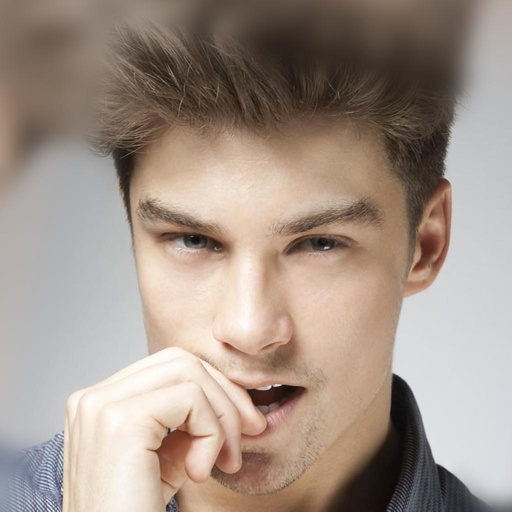

Örnek görsel: 7604.jpg — 512×512


In [ ]:
# ── CELL 8: Doğrulama ────────────────────────────────────────────────────────
import random

dosyalar = os.listdir(TRAIN_DIR)
jpg_say  = len([f for f in dosyalar if f.endswith('.jpg')])
txt_say  = len([f for f in dosyalar if f.endswith('.txt')])

print(f'📂 {TRAIN_DIR}')
print(f'   .jpg : {jpg_say:,}')
print(f'   .txt : {txt_say:,}')
print()

txt_files = [f for f in dosyalar if f.endswith('.txt')]
print('🔍 Örnek caption\'lar:')
for fname in random.sample(txt_files, min(5, len(txt_files))):
    with open(os.path.join(TRAIN_DIR, fname)) as f:
        print(f'  {fname} → {f.read()}')

# Bir görseli göster
from IPython.display import display
sample_jpg = random.choice([f for f in dosyalar if f.endswith('.jpg')])
display(Image.open(os.path.join(TRAIN_DIR, sample_jpg)))
print(f'Örnek görsel: {sample_jpg} — 512×512')